Wahlpflichtfach Künstliche Intelligenz I: Testat

---

# 02 - Testat zu Scikit-learn (sklearn)
__Gruppennummer:__ 3

__Mitglieder:__
- Marcel Kecker
- Marcel Woker
- Henry Brüning
- Leonhard Ruckert
- Eddy Utikal

In [1]:
%matplotlib inline

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In diesem Testat werden Sie die unterschiedlichen Arbeitsschritte von der Datenvorverarbeitung über die Modell- und Teststrategieauswahl bis hin zur Evaluierung mit Hilfe von Scikit-learn durchführen. Dabei verwenden wir eine leicht modifizierte Variante des [California Housing Datasets](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset). Dieses enthält die folgenden _acht_ Merkmale:
- __MedInc:__ Das mittlere Einkommen im Block
- __HouseAge:__ Das mittlere Hausalter im Block
- __AveRooms:__ Die durchschnittliche Raumanzahl pro Haushalt im Block
- __AveBedrms:__ Die durchschnittliche Schlafzimmeranzahl pro Haushalt im Block
- __Population:__ Die Bevölkerunganzahl im Block
- __AveOccup:__ Die durchschnittliche Anzahl von Personen pro Haushalt im Block
- __Latitude:__ Der Breitengrad des Blocks
- __Longitude:__ Der Längengrad des Blocks

Jedem Datenpunkt ist genau einer Klasse (_low_, _mid-low_, _mid_, _mid-high_, _high_) zugeordnet, die angibt, wie hoch der mittlere Hauswert im Block ist. Jede Klasse enthält ~20% der Datenpunkte.

## Aufgabe 0 - Data Understanding
__unbenotet__

Laden Sie die Daten und machen Sie sich mit ihnen vertraut. 

In [3]:
housing_df = pd.read_csv('california_housing_data.csv')


Eventuell hilft Ihnen auch der folgende Graph.

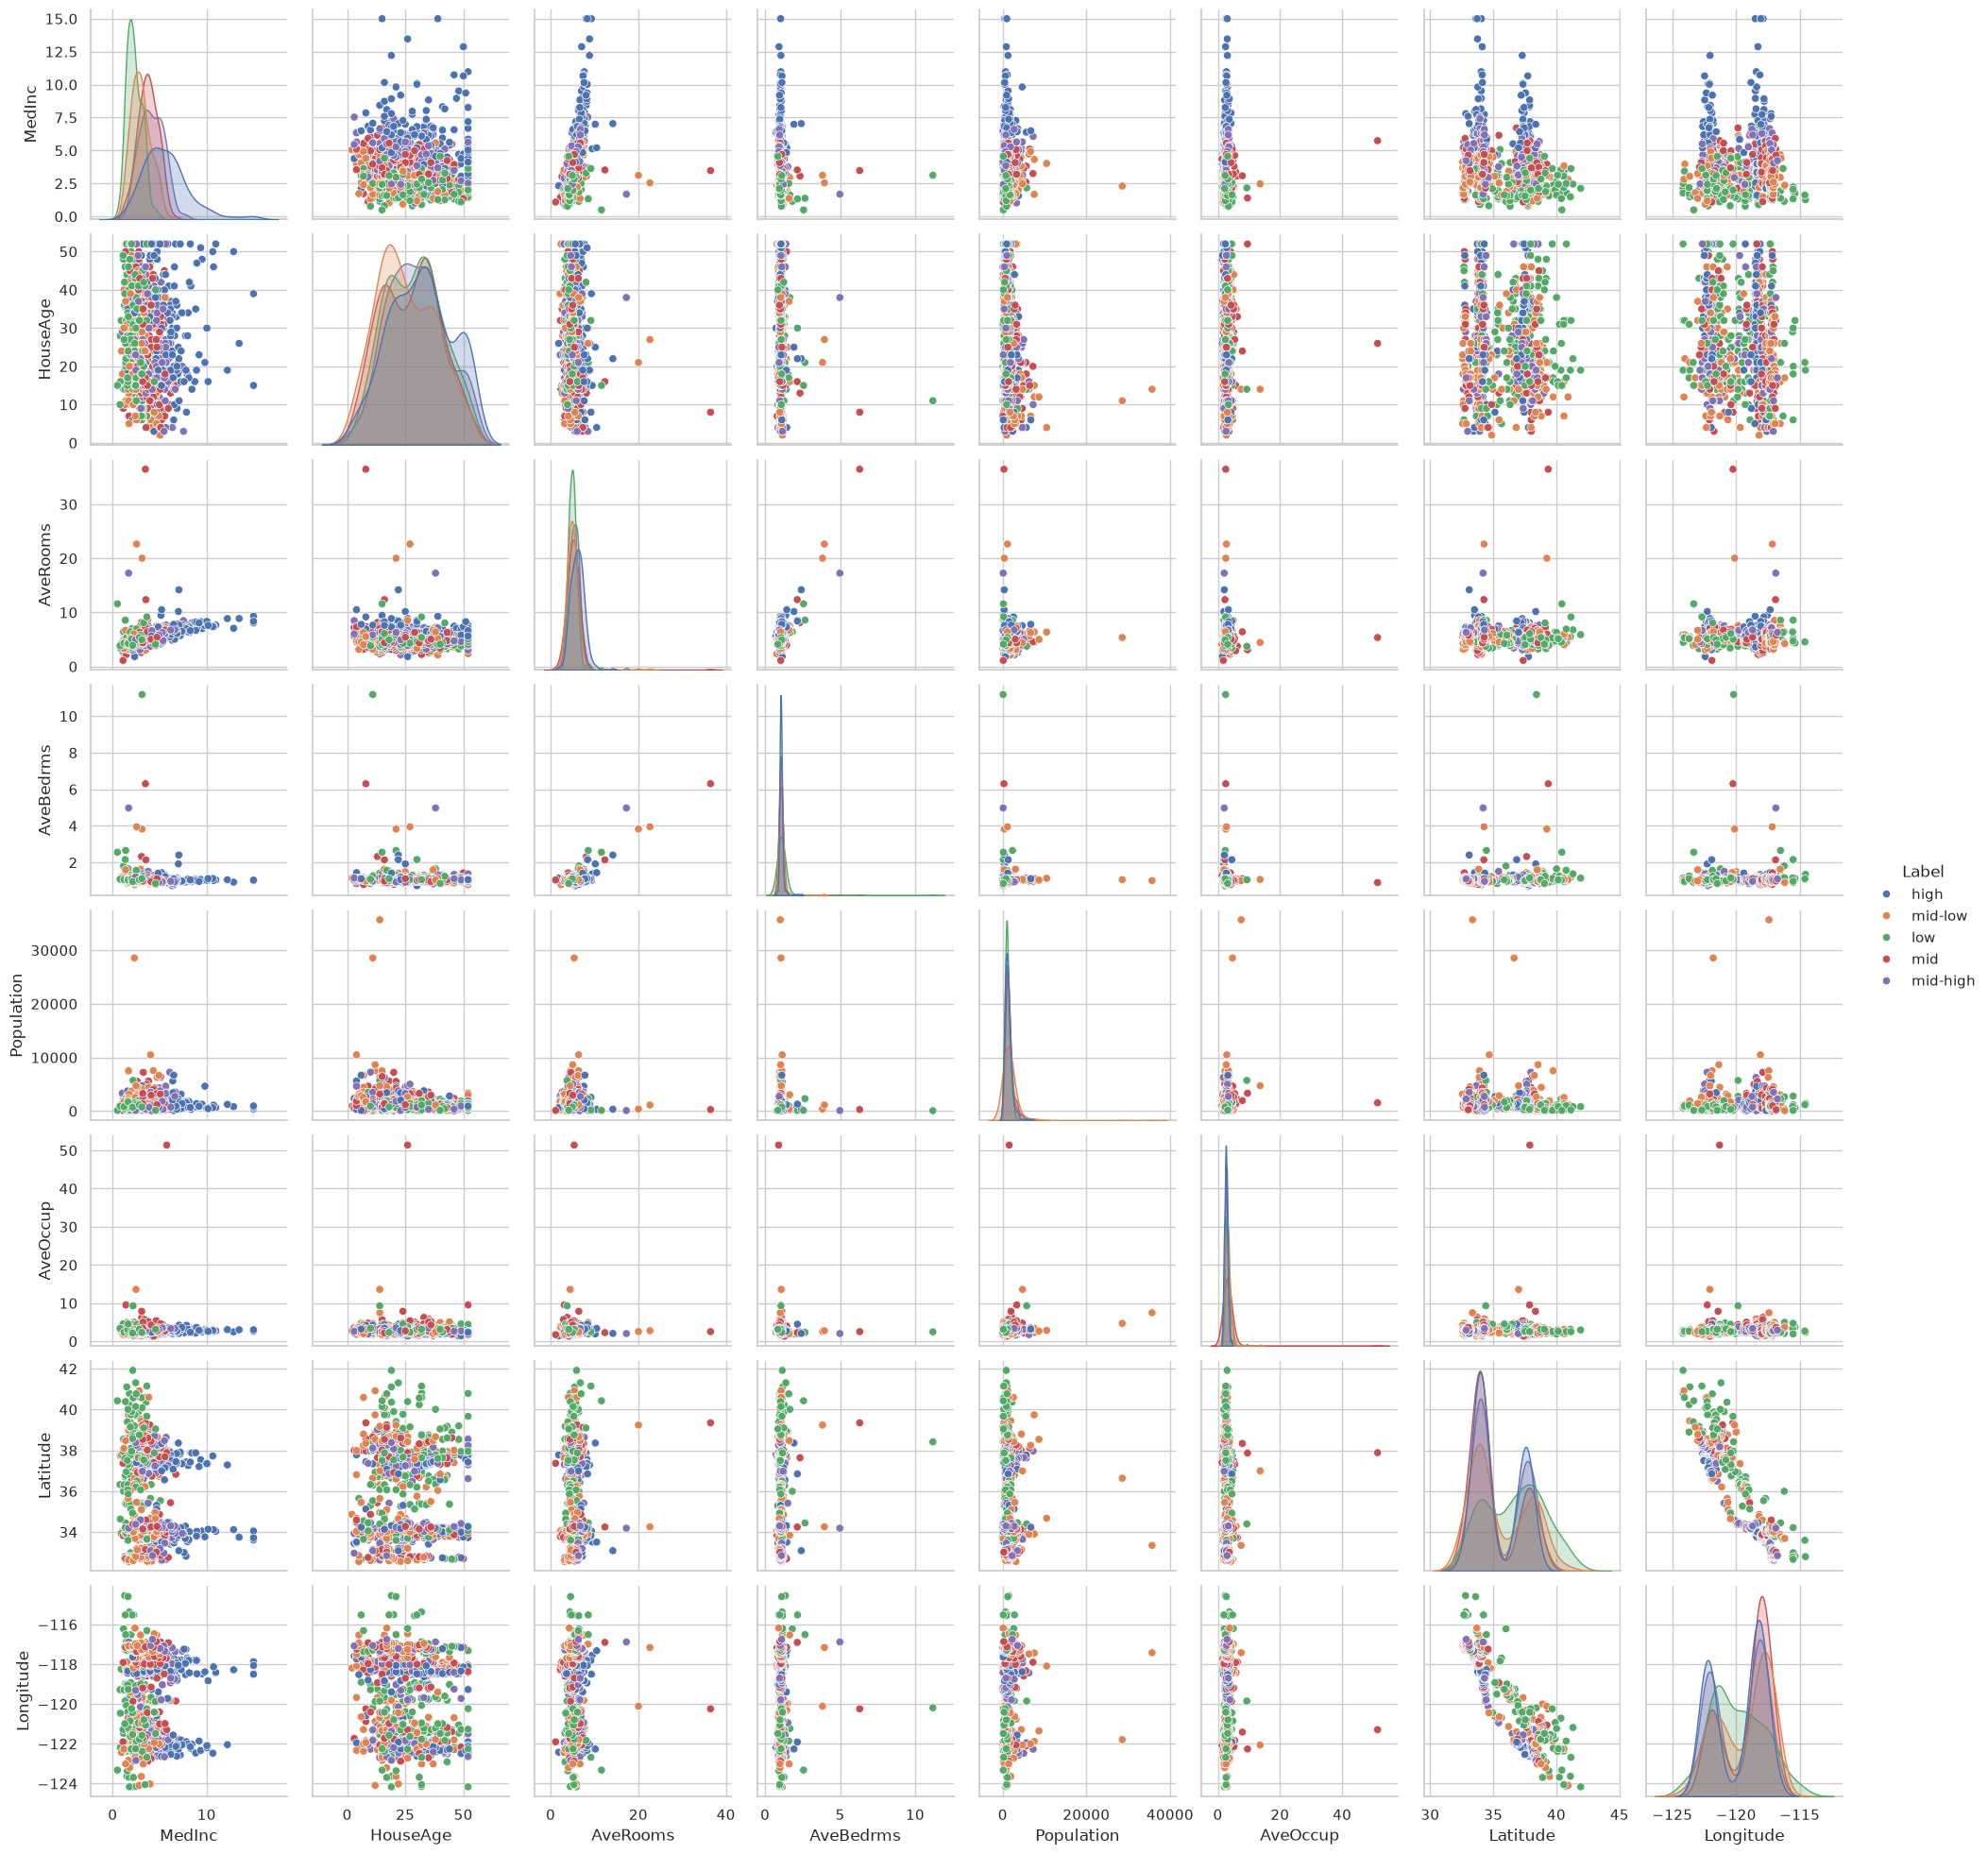

In [4]:
sns.set_theme(style="whitegrid")
sns.pairplot(housing_df, hue="Label")

## Aufgabe 1 - Data Preparation (4 Punkte)
Die erste Aufgabe ist es den Datensatz fürs maschinelle Lernen vorzubereiten. Dazu sind die folgenden Schritte nötig:
- a) Auswahl der Strategie(n) zum Ersetzen der fehlenden Werte
- b) Auswahl der Strategie(n) zur Skalierung der Daten
- c) Erstellen der Preparation-Pipeline

Da das Ersetzen der fehlenden Werte und die Skalierung der Daten in einer `Pipeline` passieren soll, können Sie nur Algorithmen verwenden, die __sklearn__ bereitstellt.

_Hinweise/Tipps:_ 
- Sie müssen die unterschiedlichen Algorithmen nicht (bis zum Maximum) optimieren, hier geht es gerade eher darum zu überprüfen, ob Sie die Algorithmen generell verstanden haben und Sie richtig einsetzen/kombinieren können.
- Gucken Sie sich nochmal die besprochenen Algorithmen an und überlegen wo die Stärken und Schwächen liegen.
- Sie können selbstverständlich auch unterschiedliche Methoden für die einzelnen Merkmale wählen.  

### a) Auswahl der Strategie(n) zum Ersetzen der fehlenden Werte
_Punkte: 1_

Als erstes müssen Sie sich eine Strategie zum Ersetzen der fehlenden Werte überlegen. Beschreiben Sie diese in der nachfolgenden Markdown-Zeile und begründen Sie, warum Sie diese Strategie gewählt haben. 

__Ihre Antwort:__

Nicht löschen, da 334 Zeilen fehlende Werte haben und somit etwa 4% der Daten gelöscht werden 

Median besser geeignet als Mittelwert, da es viele Ausreißer gibt (z. B. Population: Median=1.150 Mittelwert=1466)

-> Entscheidung: Median

### b) Auswahl der Strategie(n) zur Skalierung der Daten
_Punkte: 1_

Außerdem sollten die Daten skaliert/normalisiert werden. Beschreiben Sie Ihre Strategie und begründen Sie warum Sie diese Strategie bzw. Methoden gewählt haben.

__Ihre Antwort:__

Bis zu 65 Ausreißer (Werte außerhalb 1,5*IQR) in einer Spalte => Skalierungsmethode, die Ausreißer nicht stark beachtet

Deswegen Robustskalierung

### c) Erstellen der Preparation-Pipeline
_Punkte: 2_

In der nächsten Codezeile können Sie nun die `preparation_pipeline` erstellen. In dieser sollen beide vorherigen Schritte enthalten sein. Sie müssen die Pipeline aber noch nicht "trainieren" (Aufruf der Methode `fit()`).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

### BEGIN SOLUTION
preparation_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])
### END SOLUTION

Warum macht es noch keinen Sinn die Pipeline jetzt schon zu trainieren?

__Ihre Antwort:__

Weil die Daten zuerst in Trainings- und Testdaten unterteilt werden müssen.

Sonst wird mit Testdaten trainiert -> Datenleck

## Aufgabe 2 - Trainingsvorbereitung und Modellauswahl  (4 Punkte)
Ihre nächste Aufgabe ist es das Training vorzubereiten und den richtigen ML-Algorithmus auszuwählen. Dafür müssen Sie die folgenden Teilaufgaben erledigen:
- a) Erstellen des Test- und Trainingsdatenset
- b) Kreuzvalidierung im Trainingsprozess
- c) Optimieren eines ML-Algorithmus
- d) Testen der trainierten Pipeline

### a) Erstellen des Test- und Trainingsdatenset
_Punkte: 0,5_

Zuerst benötigen wir ein Test- und ein Trainingsdatenset. Das Testdatenset soll 30% der gesamten Daten enthalten. 

In [ ]:
from sklearn.model_selection import train_test_split

# get the data and target from the data frame 
data = housing_df.loc[:, :'Longitude']
target = housing_df['Label']

### BEGIN SOLUTION
train_data, test_data, train_label, test_label = train_test_split(
    data,
    target,
    test_size=0.3,
    random_state=0
)
### END SOLUTION

### b) Kreuzvalidierung im Trainingsprozess
_Punkte: 1_

Was ist unter Kreuzvalidierung im Trainingsprozess zu verstehen und wieso wird es verwendet?

__Ihre Antwort:__

Trainingsdaten werden in Folds eingeteilt. Beim Trainieren des Models mit einem Fold wird das Model mit einem anderen Fold getestet.

Damit kann schon während des Trainingsprozesses geprüft werden, wie gut das Model mit untrainierte Daten umgeht

### c) Optimieren eines ML-Algorithmus
_Punkte: 1,5_

Im nächsten Schritt optimieren wir einen ML-Algorithmus. Da wir ein Klassifikationsproblem lösen wollen, kommen nur Klassifikationsalgorithmen als mögliche Algorithmen in Frage. Wir werden den [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) verwenden. 

Der `RandomForestClassifier` soll eine maximale Tiefe von 6 haben und maximal 75% der Daten pro Baum verwenden. Setzen Sie den `random_state` auf 0. Für die Anzahl der Bäume sollen die folgenden Werte überprüft werden: `[30, 40, 50, 60, 70, 80]`. Außerdem sollen die beiden Möglichkeiten `['gini', 'entropy']` für das Kriterium, nach dem geteilt wird, getestet werden.

Führen Sie die folgenden Schritte durch:
- Erstellen Sie eine Pipeline, die zuerst die vorher bereits erstellte Vorverarbeitung durchführt und anschließend den `RandomForestClassifier` aufruft. 
- Finden Sie die optimalen Parameter aus den angegebenen Parameterbereichen.
- Speichern Sie die `Pipeline` mit den besten Parametern in der Variable `trained_pipeline`
- Geben Sie die beste `Pipeline` aus

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

### BEGIN SOLUTION

# Pipeline erstellen
pipeline = Pipeline([
    ("preparation", preparation_pipeline),
    ("classifier", RandomForestClassifier(
        max_depth=6,
        max_samples=0.75,
        random_state=0
    ))
])

# Zu testende Parameter
param_grid = {
    "classifier__n_estimators": [30, 40, 50, 60, 70, 80],
    "classifier__criterion": ["gini", "entropy"]
}

# Grid Search mit Cross-Validation
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5 # 5 Fold Cross-Validation
)

# Training und Parametersuche
grid_search.fit(train_data, train_label)

# Beste Pipeline speichern
trained_pipeline = grid_search.best_estimator_

# Beste Pipeline ausgeben
print(trained_pipeline)

### END SOLUTION

Pipeline(steps=[('preparation',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', RobustScaler())])),
                ('classifier',
                 RandomForestClassifier(criterion='entropy', max_depth=6,
                                        max_samples=0.75, n_estimators=30,
                                        random_state=0))])


### d) Testen der trainierten Pipeline
_Punkte: 1_

Nachdem Sie die `Pipeline` trainiert haben, ist es nun Zeit diese zu testen. Lassen Sie sich dafür den Score einmal für das Test- und einmal für das Trainingsdatenset berechnen. Was fällt auf? Welche Metrik wird für das berechnen verwendet bzw. was sagt sie aus? Ist diese Metrik hier sinnvoll?

In [10]:
### BEGIN SOLUTION

train_score = trained_pipeline.score(train_data, train_label)
test_score = trained_pipeline.score(test_data, test_label)

print("Trainingsscore:", train_score)
print("Testscore:", test_score)

### END SOLUTION

Trainingsscore: 0.814404432132964
Testscore: 0.5032258064516129


__Ihre Antwort:__

Der Score wird als Accuracy (Genauigkeit) angegeben. Sie beschreibt den Anteil der Daten, die das Modell richtig klassifiziert hat. Dies ist hier sinnvoll, da so ein guter Überblick über die Qualität des Modells geschaffen werden kann.

Der Score mit Trainingsdaten ist deutlich höher, da das Model auf genau diese Daten trainiert wurde. Zwischen Trainingsscore und Testscore liegen über 30% Unterschied -> Die Baumstruktur hat sich zu stark an die Trainingsdaten angepasst (Overfitting)

Dennoch kann mit Modell ein grundlegendes Verständnis über Klassifizierung von Wohnblöcken in Kalifornien gewonnen werden (50% Genauigkeit).

## Aufgabe 3 - Weitere Evaluierung und Visualisierung (2 Punkte)
Im letzten Schritt wollen wir uns die Ergebnisse noch einmal genauer angucken, um eventuell zu verstehen, was passiert ist. Dazu sind die folgenden Teilaufgaben zu erledigen:
- a) Erstellen eines Confusion Matrix-Diagramms
- b) Analyse des Einfluss des Parameters n_estimators auf das Ergebnis

### a) Erstellen eines Confusion Matrix-Diagramms
_Punkte: 1_

Erstellen Sie mit Hilfe der `ConfusionMatrixDisplay`-Funktion das Diagramm der Confusion Matrix. Analysieren Sie dieses anschließend.

_Tipps:_
- Welche Klassen wurden falsch klassifiziert?
- Was könnten mögliche Gründe dafür sein?

In [ ]:
### BEGIN SOLUTION
from sklearn.metrics import ConfusionMatrixDisplay

###Vorhersagen auf den Testdaten
predictions = trained_pipeline.predict(test_data)

### Confusion Matrix visualisieren
confusion_matrix = ConfusionMatrixDisplay.from_predictions(
    test_label,
    predictions,
    labels=trainedpipeline.classes,
    display_labels=trainedpipeline.classes,
    cmap=plt.cm.Blues,
)

confusionmatrix.ax.set_title("Confusion Matrix")
confusionmatrix.ax.set_xlabel("Vorhergesagte Klasse")
confusionmatrix.ax.set_ylabel("Tatsächliche Klasse")
plt.tight_layout()
plt.show()
### END SOLUTION

__Ihre Antwort:__

In der Confusion Matrix werden vor allem benachbarte Klassen verwechselt.
"low" und "mid-low" 
"mid-low" und "mid"
"mid" und "mid-high"
"mid-high" und "high"
Das kann passieren, da die Klassen nach Wohnwerten geordnet sind und die Merkmale der angrenzenden Klassen sehr ähnlich sein können.

Mögliche Gründe dafür sind, dass die Grenzen zwischen den Klassen nicht klar getrennt sind und viele Merkmale wie Einkommen, Lage und Hausalter sich in benachbarten Kategorien stark überlappen. Außerdem können Ausreißer, fehlende Werte oder räumliche Unterschiede im Datensatz dazu führen, dass das Modell an den Klassengrenzen unsicher wird. Deshalb entstehen eher Verwechslungen zwischen Nachbarklassen als zwischen weit entfernten Klassen.

### b) Analyse des Einfluss des Parameters n_estimators auf das Ergebnis
_Punkte: 1_

Zum Schluss wollen wir noch einmal analysieren welchen Einfluss der Parameter `n_estimators` auf das Trainingsergebnis hat. Verwenden Sie dafür die Funktion `validation_curve`, um für den getesteten Parameterbereich des Parameters die nötigen Daten zu sammeln. Speichern Sie die Rückgabe in den Variablen `train_scores` und `valid_score`. Erstellen Sie außerdem eine Variable `n_estimators`, die alle möglichen Werte für den Parameter enthält. 

Welche Rückschlüsse lässt das Diagramm zu?

In [ ]:

### BEGIN SOLUTION
from sklearn.model_selection import validation_curve

n_estimators = [30, 40, 50, 60, 70, 80]

train_scores, valid_scores = validation_curve(
    trained_pipeline,
    train_data,
    train_label,
    param_name="classifier__n_estimators",
    param_range=n_estimators,
    cv=5,
    scoring="accuracy",
)
### END SOLUTION

In [ ]:
# first, calculate the means and standard deviations
train_scores_mean = train_scores.mean(axis=1)  # noqa: F821
train_scores_std = train_scores.std(axis=1)  # noqa: F821
valid_scores_mean = valid_scores.mean(axis=1)  # noqa: F821
valid_scores_std = valid_scores.std(axis=1)  # noqa: F821

# create the figure
plt.figure(figsize=(10, 10))
plt.title("Validation Curve of RandomForestClassifier with different n_estimators values")
plt.xlabel("n_estimators")
plt.ylabel("Score")
# plot the training score
plt.plot(n_estimators, train_scores_mean, label="Training score", color="darkorange")  # noqa: F821
plt.fill_between(
    n_estimators,   # noqa: F821
    train_scores_mean - train_scores_std, 
    train_scores_mean + train_scores_std, 
    color="darkorange",
    alpha=0.2
)
# plot the validation score
plt.plot(n_estimators, valid_scores_mean, label="Cross-validation score", color="navy")  # noqa: F821
plt.fill_between(
    n_estimators,  # noqa: F821
    valid_scores_mean - valid_scores_std,
    valid_scores_mean + valid_scores_std,
    color="navy",
    alpha=0.2
)

plt.legend(loc="best")
plt.show()

__Ihre Antwort:__

Mit steigender Anzahl an Bäumen steigt der Trainingsscore leicht von etwa 0,81 auf etwa 0,83. Der Cross-Validation-Score verbessert sich dagegen nicht. Er liegt bei 30 bis 40 Bäumen bei ungefähr 0,49, sinkt bis 60 Bäume auf etwa 0,47 und steigt bei 80 Bäumen nur leicht auf etwa 0,49.

Für diesen getesteten Bereich bringen mehr als etwa 30 bis 40 Bäume daher keinen erkennbaren Vorteil für die Generalisierung. Der beste Validierungswert wird mit 30 Bäumen erreicht. Die zunehmende Lücke zwischen Trainings- und Validierungsscore deutet darauf hin, dass das Modell mit mehr Bäumen zwar besser auf den Trainingsdaten abschneidet, die zusätzliche Komplexität aber nicht zu einer besseren Leistung auf unbekannten Daten führt.

---

Wahlpflichtfach Künstliche Intelligenz I: Testat